<a href="https://colab.research.google.com/github/kjesinthuyaUCLL/mbti-tune/blob/main/MBTI_Tune_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1: Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

# Verify your data folder exists
!ls "/content/drive/My Drive/mbti_tune_data/"

Mounted at /content/drive
features.json  scaler.pkl  test.pt  train.pt  val.pt


In [ ]:
# 2: Install Libraries (run once per session)

!pip install torch torchvision --quiet
!pip install scikit-learn matplotlib seaborn shap --quiet
!pip install tqdm --quiet

print("✅ Libraries installed!")

✅ Libraries installed!


In [ ]:
# 3: Imports & GPU Check

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [ ]:
# 4: Load Data from Google Drive

import torch
import json
import pickle
import pandas as pd  # Add this import

DATA_PATH = "/content/drive/My Drive/mbti_tune_data/"

# Add pandas DataFrame to safe globals for secure loading
import torch.serialization
# The problematic global was pandas.core.internals.managers.BlockManager, not pd.DataFrame.
# However, the most robust fix is to disable weights_only if the data is trusted.
# torch.serialization.add_safe_globals([pd.DataFrame])

# Now load with weights_only=False as suggested by the error message (secure if source is trusted)
train_data = torch.load(f"{DATA_PATH}/train.pt", weights_only=False)
val_data = torch.load(f"{DATA_PATH}/val.pt", weights_only=False)
test_data = torch.load(f"{DATA_PATH}/test.pt", weights_only=False)

# Extract components
X_train, y_train, w_train = train_data['X'], train_data['y'], train_data['weights']
X_val, y_val, w_val = val_data['X'], val_data['y'], val_data['weights']
X_test, y_test, w_test = test_data['X'], test_data['y'], test_data['weights']
metadata_test = test_data['metadata']

# Load feature names
with open(f"{DATA_PATH}/features.json", 'r') as f:
    feature_names = json.load(f)

print(f"✅ Data loaded successfully!")
print(f"\n📊 Dataset sizes:")
print(f"   Training:   {X_train.shape[0]:,} samples x {X_train.shape[1]} features")
print(f"   Validation: {X_val.shape[0]:,} samples x {X_val.shape[1]} features")
print(f"   Test:       {X_test.shape[0]:,} samples x {X_test.shape[1]} features")
print(f"\n📊 Features: {feature_names}")

✅ Data loaded successfully!

📊 Dataset sizes:
   Training:   22,656 samples x 14 features
   Validation: 3,237 samples x 14 features
   Test:       6,474 samples x 14 features

📊 Features: ['BPM', 'Energy', 'Dance', 'Acoustic', 'Instrumental', 'Valence', 'Speech', 'Live', 'Popularity', 'Loud (Db)', 'Duration_sec', 'Camelot_num', 'Key_num', 'Time Signature']


In [ ]:
# 5: Autoencoder Model Definition

class Autoencoder(nn.Module):
    """
    Autoencoder neural network with:
    - Encoder: 14 features -> 16-dim bottleneck (compressed representation)
    - Decoder: 16-dim -> reconstruct original 14 features
    """
    def __init__(self, input_dim=14, bottleneck_dim=16):
        super(Autoencoder, self).__init__()

        # Encoder: compresses input to bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, bottleneck_dim),
            nn.BatchNorm1d(bottleneck_dim),
            nn.ReLU()
        )

        # Decoder: reconstructs from bottleneck
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def encode(self, x):
        return self.encoder(x)

# Initialize model
autoencoder = Autoencoder(input_dim=X_train.shape[1], bottleneck_dim=16)
autoencoder = autoencoder.to(device)
print(autoencoder)
print(f"\n✅ Autoencoder created with {sum(p.numel() for p in autoencoder.parameters()):,} parameters")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=6

Training Autoencoder...
--------------------------------------------------
Epoch  20/100 | Train Loss: 0.221888 | Val Loss: 0.102556
Epoch  40/100 | Train Loss: 0.202483 | Val Loss: 0.084217
Epoch  60/100 | Train Loss: 0.187661 | Val Loss: 0.076086
Epoch  80/100 | Train Loss: 0.179040 | Val Loss: 0.070594
Epoch 100/100 | Train Loss: 0.169630 | Val Loss: 0.067531


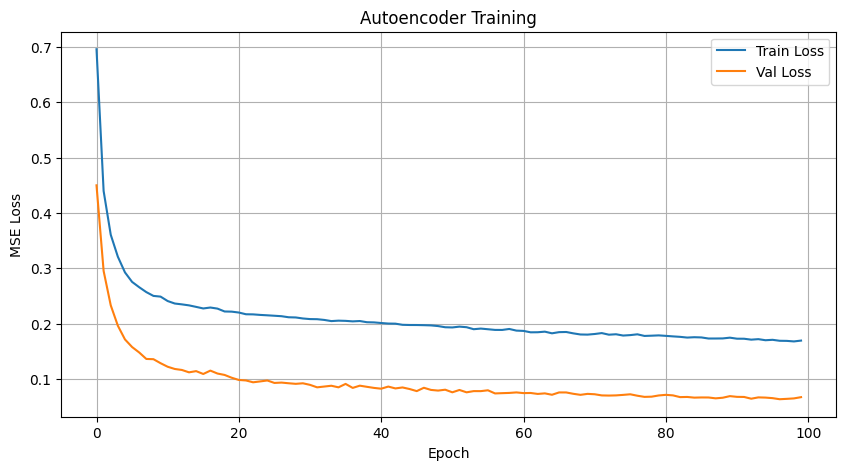


✅ Autoencoder saved to Google Drive: autoencoder.pth


In [ ]:
# 6: Train Autoencoder

def train_autoencoder(model, X, X_val, epochs=100, batch_size=256, lr=0.001):
    """Train autoencoder to reconstruct input features"""

    # Create dataloaders
    train_dataset = TensorDataset(X)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    train_losses = []
    val_losses = []

    print("Training Autoencoder...")
    print("-" * 50)

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch in train_loader:
            x = batch[0].to(device)
            _, reconstructed = model(x)
            loss = criterion(reconstructed, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch[0].to(device)
                _, reconstructed = model(x)
                val_loss += criterion(reconstructed, x).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    return train_losses, val_losses

# Combine all data for pretraining (use training + validation)
X_all = torch.cat([X_train, X_val], dim=0)

# Train
train_losses, val_losses = train_autoencoder(autoencoder, X_all, X_val, epochs=100)

# Plot training curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training')
plt.legend()
plt.grid(True)
plt.show()

# Save the trained autoencoder
torch.save(autoencoder.state_dict(), "/content/drive/My Drive/mbti_tune_data/autoencoder.pth")
print("\n✅ Autoencoder saved to Google Drive: autoencoder.pth")

In [ ]:
# 7: MBTI Classifier Model

class MBTIClassifier(nn.Module):
    """
    Multi-output regression model that predicts 4 MBTI dimension scores
    Uses pretrained autoencoder encoder as feature extractor
    """
    def __init__(self, autoencoder_encoder, input_dim=14, hidden_dim=64):
        super(MBTIClassifier, self).__init__()

        # Use pretrained encoder (frozen at first)
        self.encoder = autoencoder_encoder

        # Classification heads for each MBTI dimension
        self.classifier = nn.Sequential(
            nn.Linear(16, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 4),  # 4 dimensions (E, N, T, J)
            nn.Sigmoid()       # Output between 0-1 (percentage)
        )

    def forward(self, x):
        features = self.encoder(x)   # 14 -> 16-dim bottleneck
        outputs = self.classifier(features)  # 16 -> 4 percentages
        return outputs

# Create classifier using pretrained encoder
classifier = MBTIClassifier(autoencoder.encoder)
classifier = classifier.to(device)

print(classifier)
print(f"\n✅ Classifier created with {sum(p.numel() for p in classifier.parameters()):,} parameters")

MBTIClassifier(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


Dimension weights (E,N,T,J): [1.3758389 1.0913874 1.436129  1.1173831]

Training Classifier...
------------------------------------------------------------
Epoch  20/150 | Loss: 1.0246 | Val Loss: 1.0102 | Acc: 0.42%
Epoch  40/150 | Loss: 1.0161 | Val Loss: 1.0052 | Acc: 0.65%
Epoch  60/150 | Loss: 1.0151 | Val Loss: 1.0056 | Acc: 0.69%
Epoch  80/150 | Loss: 1.0133 | Val Loss: 1.0042 | Acc: 0.71%
Epoch 100/150 | Loss: 1.0097 | Val Loss: 1.0029 | Acc: 0.77%
Epoch 120/150 | Loss: 1.0082 | Val Loss: 1.0018 | Acc: 0.70%
Epoch 140/150 | Loss: 1.0070 | Val Loss: 1.0025 | Acc: 1.03%


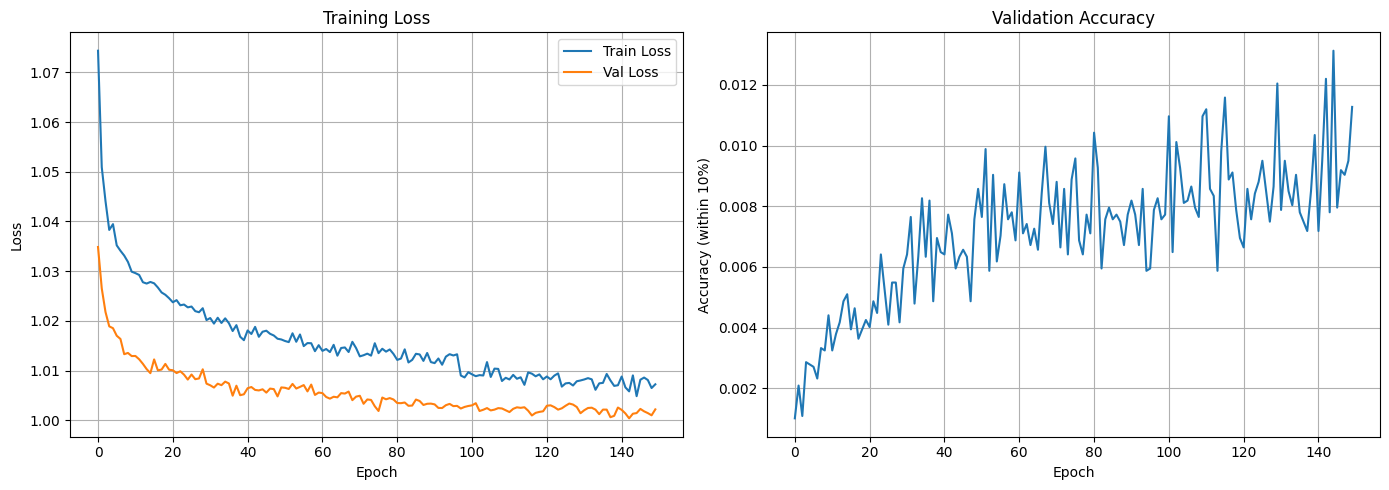


✅ Classifier saved to Google Drive: mbti_classifier.pth


In [ ]:
# 8: Train MBTI Classifier

def calculate_dimension_weights(y_train):
    """Calculate weights for handling dimension imbalance"""
    weights = []
    for dim in range(4):
        n_pos = y_train[:, dim].sum()
        n_neg = len(y_train) - n_pos
        weight_pos = n_neg / n_pos if n_pos > 0 else 1.0
        weights.append(weight_pos)
    return torch.tensor(weights, device=device)

# Calculate dimension weights
dim_weights = calculate_dimension_weights(y_train.numpy())
print(f"Dimension weights (E,N,T,J): {dim_weights.cpu().numpy()}")

def train_classifier(model, train_data, val_data, epochs=150, batch_size=128, lr=0.001):
    """Train classifier with sample weights and dimension weights"""

    X_train, y_train, w_train = train_data
    X_val, y_val, w_val = val_data

    # Create weighted dataloader (using sample weights)
    train_dataset = TensorDataset(X_train, y_train, w_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val, y_val, w_val)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Loss with dimension weights
    criterion = nn.BCELoss(weight=dim_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

    train_losses = []
    val_losses = []
    val_accuracies = []

    print("\nTraining Classifier...")
    print("-" * 60)

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch in train_loader:
            x, y, w = batch
            x, y, w = x.to(device), y.to(device), w.to(device)

            # Apply sample weights to loss
            outputs = model(x)
            loss = (criterion(outputs, y) * w).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for batch in val_loader:
                x, y, w = batch
                x, y, w = x.to(device), y.to(device), w.to(device)
                outputs = model(x)
                loss = (criterion(outputs, y) * w).mean()
                val_loss += loss.item()
                val_preds.append(outputs.cpu())
                val_targets.append(y.cpu())

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Calculate accuracy (within 10% tolerance)
        val_preds = torch.cat(val_preds, dim=0)
        val_targets = torch.cat(val_targets, dim=0)
        accuracy = (torch.abs(val_preds - val_targets) < 0.1).float().mean().item()
        val_accuracies.append(accuracy)

        scheduler.step(val_loss)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {accuracy:.2%}")

    return train_losses, val_losses, val_accuracies

# Train classifier
train_losses, val_losses, val_accuracies = train_classifier(
    classifier,
    (X_train, y_train, w_train),
    (X_val, y_val, w_val),
    epochs=150,
    batch_size=128
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_accuracies)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (within 10%)')
axes[1].set_title('Validation Accuracy')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Save trained classifier
torch.save(classifier.state_dict(), "/content/drive/My Drive/mbti_tune_data/mbti_classifier.pth")
print("\n✅ Classifier saved to Google Drive: mbti_classifier.pth")


TEST SET EVALUATION

Extraversion (E):
  MAE:  0.423 (avg error: 42.3%)
  RMSE: 0.462
  R²:   0.124

Intuition (N):
  MAE:  0.471 (avg error: 47.1%)
  RMSE: 0.485
  R²:   0.057

Thinking (T):
  MAE:  0.430 (avg error: 43.0%)
  RMSE: 0.463
  R²:   0.112

Judging (J):
  MAE:  0.472 (avg error: 47.2%)
  RMSE: 0.484
  R²:   0.059


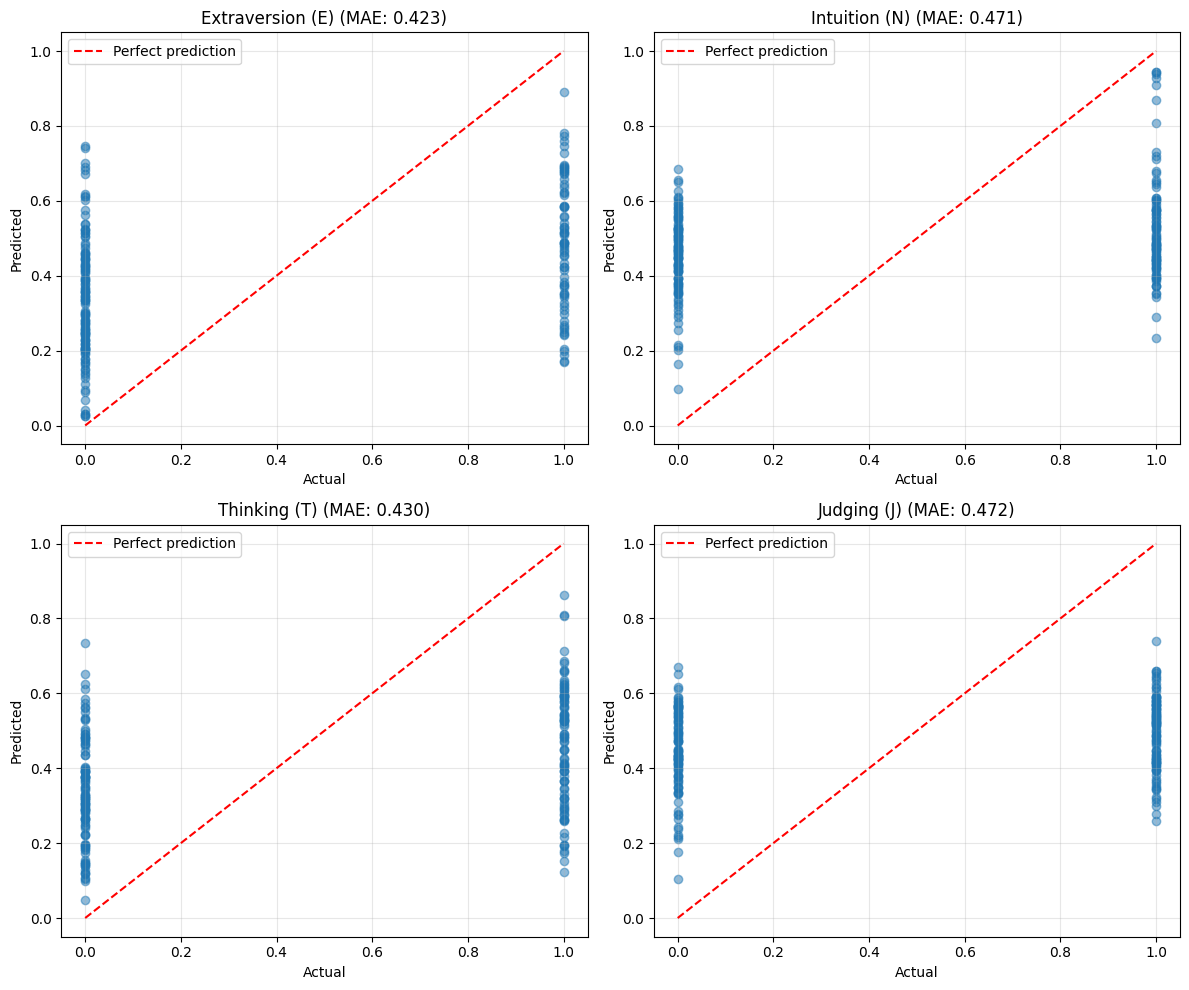

In [ ]:
# 9: Test Set Evaluation

def evaluate_model(model, X_test, y_test, feature_names):
    """Evaluate model and return metrics"""
    model.eval()
    with torch.no_grad():
        X_test = X_test.to(device)
        predictions = model(X_test).cpu().numpy()
        targets = y_test.numpy()

    # Calculate metrics per dimension
    dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']

    print("\n" + "="*60)
    print("TEST SET EVALUATION")
    print("="*60)

    results = {}
    for i, name in enumerate(dim_names):
        mae = mean_absolute_error(targets[:, i], predictions[:, i])
        rmse = np.sqrt(mean_squared_error(targets[:, i], predictions[:, i]))
        r2 = r2_score(targets[:, i], predictions[:, i])
        results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        print(f"\n{name}:")
        print(f"  MAE:  {mae:.3f} (avg error: {mae*100:.1f}%)")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")

    return predictions, targets, results

# Evaluate
predictions, targets, results = evaluate_model(classifier, X_test, y_test, feature_names)

# Plot predictions vs actual for a sample
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']

for i, (name, ax) in enumerate(zip(dim_names, axes.flatten())):
    ax.scatter(targets[:200, i], predictions[:200, i], alpha=0.5)
    ax.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name} (MAE: {results[name]["MAE"]:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()